# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
...
print( "Tỷ lệ missing của từng cột:")
print(df.isnull().mean())
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# điền danh sách cột cần bỏ (chỉ những cột có trong df)
cols_keep = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df = df[cols_keep]
# df = df.drop(columns=...)

# print("Các cột còn lại:", list(df.columns))
print("các cột còn lại:", list(df.columns))

Tỷ lệ missing của từng cột:
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` chỉ là biến `survived` được viết lại dưới dạng chữ ("yes"/"no") thay vì số (1/0) — hai cột này mang **chính xác cùng một thông tin**. Nếu giữ `alive` làm đặc trưng đầu vào, mô hình không cần học bất kỳ quy luật thực sự nào từ các đặc trưng khác (giới tính, tuổi, hạng vé...) mà chỉ cần "dịch" yes → 1, no → 0 để đạt accuracy gần như 100%. Đây là **target leakage**: thông tin của chính nhãn cần dự đoán bị lọt vào tập đặc trưng, khiến mô hình trông "hoàn hảo" trên dữ liệu huấn luyện/đánh giá nhưng hoàn toàn vô dụng khi triển khai thực tế (vì lúc đó ta không hề biết trước ai sống ai chết -- đó chính là thứ ta cần dự đoán).

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print("Số dòng, số cột:", df.shape)
print("Biến mục tiêu(target): 'survived' (1=sống sót, 0=không sống sót)' \n")

df.info()
print("\n Thống kê biến số")
display(df.describe())

print("\n Thống kê biến phân loại")
display(df.describe(include="object"))


Số dòng, số cột: (891, 8)
Biến mục tiêu(target): 'survived' (1=sống sót, 0=không sống sót)' 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

 Thống kê biến số


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



 Thống kê biến phân loại


C:\Users\Vinh\AppData\Local\Temp\ipykernel_1976\3437495675.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- **Biến số (numerical):** `age`, `sibsp`, `parch`, `fare` -- các giá trị đo lường/đếm được, có ý nghĩa về khoảng cách và phép tính toán học.
- **Biến phân loại (categorical):** `sex`, `embarked` -- các nhãn rời rạc, không có thứ tự tự nhiên (nominal).
- **Biến thứ tự (ordinal, nửa số nửa phân loại):** `pclass` -- tuy là số nguyên (1, 2, 3) nhưng thực chất thể hiện thứ hạng (1 = hạng sang nhất), nên được xử lý riêng ở Task 7.
- `survived` là biến mục tiêu (target), dạng nhị phân (0/1), không phải đặc trưng đầu vào.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

mising_table = pd.DataFrame({
    "so_luong_thieu": missing_count,
    "phan_tran_thieu": missing_percent.round(2)
})
mising_table = mising_table[mising_table["so_luong_thieu"] >0]
display(mising_table)

,so_luong_thieu,phan_tran_thieu
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~19.9% | Điền bằng **median** (`SimpleImputer(strategy="median")`) | Tỷ lệ thiếu vừa phải (không quá cao để phải bỏ cột), nhưng đủ lớn để không thể bỏ dòng. `age` có phân phối hơi lệch và có outlier, nên median bền vững hơn mean (không bị kéo lệch bởi các giá trị cực trị). |
| `embarked` | ~0.22% (chỉ 2 dòng) | Điền bằng **mode** (giá trị phổ biến nhất, `SimpleImputer(strategy="most_frequent")`) | Số lượng thiếu cực kỳ nhỏ (2/891 dòng), là biến phân loại nên không tính được mean/median -- điền theo giá trị xuất hiện nhiều nhất là hợp lý và gần như không ảnh hưởng tới phân phối dữ liệu. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
# trả về số lượng outlier theo IQR
def dem_outlier_iqr(s):
    s = s.dropna()
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return int(((s < lower_bound) | (s > upper_bound)).sum())


# trả về số lượng outlier theo Z-score
def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return int((z > nguong).sum())

# for col in ["age", "fare"]:
for col in ["age", "fare"]:
    n_iqr = dem_outlier_iqr(df[col])
    n_zscore = dem_outlier_zscore(df[col])
    print(f"{col}: IQR = {n_iqr} outliers, Z-score = {n_zscore} outliers")
#     ...

print("\n Top 5 vé đắt nhất':")
display(df.sort_values("fare", ascending=False).head(5)[["pclass", "fare", "survived"]])

age: IQR = 11 outliers, Z-score = 2 outliers
fare: IQR = 116 outliers, Z-score = 20 outliers

 Top 5 vé đắt nhất':


,pclass,fare,survived
679,1,512.3292,1
258,1,512.3292,1
737,1,512.3292,1
88,1,263.0000,1
438,1,263.0000,0


**Trả lời 4 (quyết định với outlier của `fare`):**

Với `age`: IQR phát hiện 11 outlier, Z-score chỉ phát hiện 2 -- vì Z-score dùng mean/std vốn ít nhạy hơn IQR với các điểm ở đuôi phân phối khi mẫu đủ lớn và phân phối gần chuẩn.

Với `fare`: IQR phát hiện tới 116 outlier, Z-score chỉ 20 -- chênh lệch rất lớn vì `fare` lệch phải rất mạnh (right-skewed), khiến IQR (dựa trên phân vị) nhạy hơn nhiều so với Z-score (dựa trên mean/std, mà mean lại bị chính các outlier này kéo lệch).

**Quyết định: giữ lại** các outlier của `fare`, không loại bỏ. Lý do: khi kiểm tra 5 vé đắt nhất, tất cả đều thuộc `pclass = 1` (hạng nhất) -- đây là **hiện tượng thật** (vé hạng sang, suite riêng...) chứ không phải lỗi nhập liệu. Loại bỏ các dòng này sẽ làm mất thông tin quan trọng, vì thực tế `fare` cao có tương quan với khả năng sống sót cao hơn (do liên quan tới hạng vé và vị trí cabin gần boong cứu hộ).

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

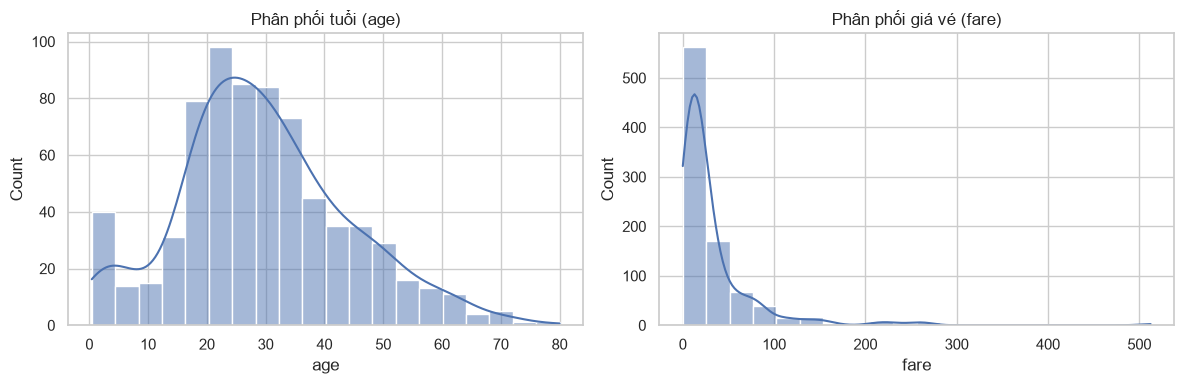

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=axes[0])
axes[0].set_title("Phân phối tuổi (age)")
sns.histplot(df["fare"].dropna(), bins=20, kde=True, ax=axes[1])
axes[1].set_title("Phân phối giá vé (fare)")
plt.tight_layout()
plt.show()

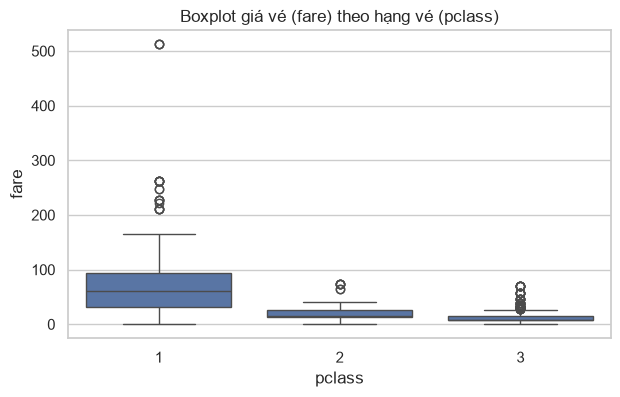

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="pclass", y="fare")
plt.title("Boxplot giá vé (fare) theo hạng vé (pclass)")
plt.show()

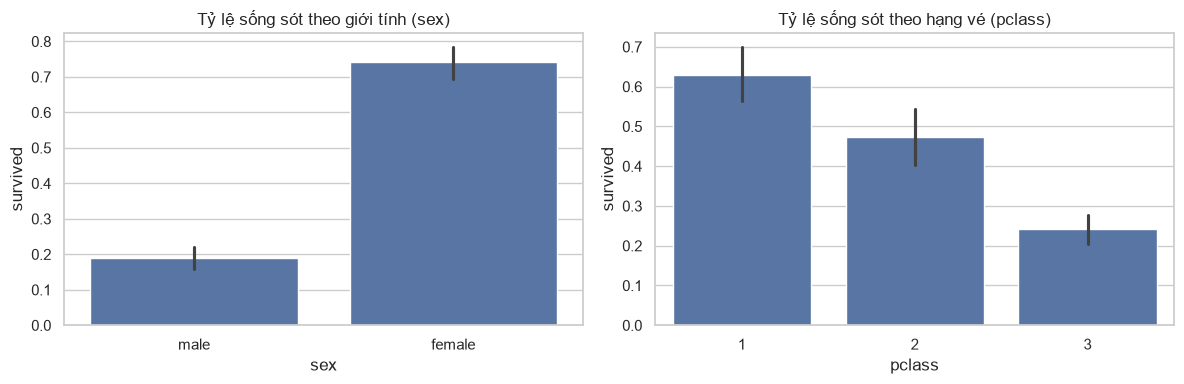

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo giới tính (sex)")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo hạng vé (pclass)")
plt.tight_layout()
plt.show()  


<Axes: >

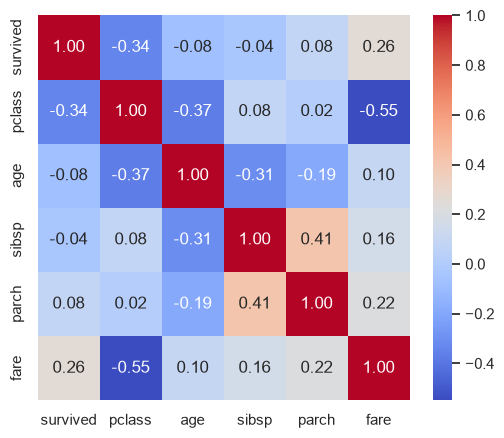

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f")

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** `age` gần với phân phối chuẩn nhưng hơi lệch phải nhẹ, tập trung nhiều ở khoảng 20-35 tuổi. `fare` lệch phải rất mạnh (right-skewed): phần lớn hành khách trả vé rẻ (dưới ~30), nhưng có một số ít vé rất đắt (đến hơn 500) kéo dài đuôi phân phối.
- **Boxplot:** `fare` của `pclass = 1` có trung vị và độ phân tán cao hơn hẳn `pclass = 2, 3`, đồng thời có nhiều điểm outlier phía trên (các vé hạng sang đặc biệt đắt). `pclass = 2` và `3` có fare thấp và ít outlier hơn.
- **Bar survival:** nữ có tỷ lệ sống sót ~74.2%, trong khi nam chỉ ~18.9% -- chênh lệch hơn 55 điểm phần trăm, cho thấy giới tính là yếu tố ảnh hưởng rất mạnh (phù hợp với chính sách "phụ nữ và trẻ em trước"). Theo hạng vé: `pclass 1` ~63%, `pclass 2` ~47%, `pclass 3` ~24.2% -- hạng vé càng cao thì tỷ lệ sống càng cao.
- **Heatmap:** `pclass` tương quan âm mạnh nhất với `survived` (khoảng -0.34), `fare` tương quan dương khá rõ (~0.26) -- hai biến này thực chất phản ánh cùng một yếu tố kinh tế-xã hội (hạng vé cao ↔ vé đắt ↔ dễ sống sót hơn). `age`, `sibsp`, `parch` có tương quan yếu với `survived`.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns="survived")
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, random_state=42, stratify=y_tmp
)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print("\nTỷ lệ sống sót:")
print("Train:", y_train.mean().round(4))
print("Val:", y_val.mean().round(4))
print("Test:", y_test.mean().round(4))


Train/Val/Test: (623, 7) (134, 7) (134, 7)

Tỷ lệ sống sót:
Train: 0.3836
Val: 0.3881
Test: 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Các tham số tiền xử lý (median để điền `age`/`fare`, mode để điền `embarked`, phạm vi (median/IQR) mà `RobustScaler` dùng để scale, danh sách category mà `OneHotEncoder` học được) đều là những con số được **học trực tiếp từ dữ liệu**. Nếu `fit` trên toàn bộ dữ liệu (bao gồm cả val/test) rồi mới chia tập, các tham số này đã "nhìn thấy" thông tin của những mẫu lẽ ra phải hoàn toàn xa lạ với mô hình -- ví dụ median của `age` sẽ bị ảnh hưởng bởi cả các hành khách trong tập test. Khi đó, hiệu năng đo được trên tập test sẽ **lạc quan giả tạo (optimistic bias)**, không còn phản ánh đúng khả năng mô hình hoạt động trên dữ liệu hoàn toàn mới trong thực tế. Bằng cách chỉ `fit` trên `X_train` rồi `transform` cho val/test, ta mô phỏng đúng tình huống thực tế: mô hình chỉ được "học" từ dữ liệu đã biết, sau đó áp dụng lên dữ liệu chưa từng thấy.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(y.value_counts(normalize=True).round(4))

survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu `survived` **mất cân bằng nhẹ**: ~61.6% không sống sót (lớp 0) và ~38.4% sống sót (lớp 1). Không quá nghiêm trọng (không phải kiểu 99%/1%), nhưng vẫn đủ lệch để cần lưu ý khi chọn metric.
2. Nếu chỉ nhìn **Accuracy**, mô hình có thể "ăn gian" bằng cách luôn dự đoán lớp đa số (không sống sót) cho mọi hành khách và vẫn đạt accuracy ~61.6% mà không học được gì cả -- con số trông có vẻ ổn nhưng hoàn toàn vô nghĩa về mặt dự đoán thực sự ai sống ai chết.
3. Với bài toán Titanic (dự đoán sống/chết), nên ưu tiên **Recall** đối với lớp "sống sót" (hoặc **F1-score** nếu muốn cân bằng cả hai) hơn là Accuracy đơn thuần, vì bỏ sót một người thực sự có khả năng sống sót (false negative) mang ý nghĩa nghiêm trọng hơn một dự đoán sai lệch quan (false positive) trong bối cảnh liên quan tới an toàn tính mạng. F1 phù hợp khi ta muốn một con số duy nhất cân bằng giữa việc không bỏ sót (recall) và không báo động giả quá nhiều (precision).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với khả năng sống sót là `sex` (chênh lệch tỷ lệ sống sót nữ ~74.2% vs nam ~18.9%, hơn 55 điểm phần trăm) và `pclass` (tương quan Pearson với `survived` khoảng -0.34, hạng 1 sống ~63% trong khi hạng 3 chỉ ~24.2%).
2. Cột thiếu nhiều nhất trong dữ liệu gốc là `deck` (~77.2%, đã bị loại ở Task 1 vì quá nhiều missing để dùng được); trong tập dữ liệu giữ lại, `age` thiếu nhiều nhất (~19.9%) và được xử lý bằng cách điền median.
3. Biến mục tiêu mất cân bằng nhẹ (61.6% / 38.4%) -- điều này khiến Accuracy đơn thuần không đủ tin cậy để đánh giá mô hình, cần bổ sung Recall/F1 để tránh bị đánh lừa bởi baseline "luôn đoán lớp đa số".
4. `age` và `fare` cần **scaling** vì có thang đo và độ phân tán rất khác nhau (đặc biệt `fare` có outlier lớn nên dùng RobustScaler); `sex` và `embarked` cần **encoding** (One-Hot) vì là biến phân loại không có thứ tự; `pclass` không cần encoding hay scaling vì đã là số nguyên có thứ tự tự nhiên (1 < 2 < 3).
5. Điều bất ngờ/thú vị: giá vé (`fare`) cao nhất trong dữ liệu (~512.33) xuất hiện ở nhiều hành khách khác nhau cùng một mức giá chính xác -- gợi ý đây có thể là các hành khách đi cùng nhóm/gia đình mua chung một loại vé đặc biệt đắt tiền, chứ không phải các giá trị ngẫu nhiên độc lập.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
df_bonus = df.copy()
df_bonus["family_size"] = df_bonus["sibsp"] + df_bonus["parch"] + 1
print("\n Thống kê biến số (có family_size)")
print(df_bonus[["family_size", "survived"]].corr())


 Thống kê biến số (có family_size)
             family_size  survived
family_size     1.000000  0.016639
survived        0.016639  1.000000


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
